In [2]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")
print("Memory:", torch.cuda.get_device_properties(0).total_memory / 1e9, "GB")

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA L40S
Memory: 47.665709056 GB


In [3]:
# ============================================================
# BLOCK 1: Gemma Scope SAE Setup + FVU Sanity Check
# ============================================================
import torch
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer
from huggingface_hub import hf_hub_download

torch.set_grad_enabled(False)

MODEL_NAME = "google/gemma-2-2b-it"
LAYER_IDX  = 20
SAE_REPO   = "google/gemma-scope-2b-pt-res"
SAE_FILE   = "layer_20/width_16k/average_l0_71/params.npz"

print(f"Loading {MODEL_NAME}...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, device_map="cuda", torch_dtype=torch.bfloat16,
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Model loaded. n_layers={len(model.model.layers)}, d_model={model.config.hidden_size}")

class JumpReLUSAE(torch.nn.Module):
    def __init__(self, d_model, d_sae):
        super().__init__()
        self.W_enc     = torch.nn.Parameter(torch.zeros(d_model, d_sae))
        self.W_dec     = torch.nn.Parameter(torch.zeros(d_sae, d_model))
        self.threshold = torch.nn.Parameter(torch.zeros(d_sae))
        self.b_enc     = torch.nn.Parameter(torch.zeros(d_sae))
        self.b_dec     = torch.nn.Parameter(torch.zeros(d_model))

    def encode(self, x):
        pre = x @ self.W_enc + self.b_enc
        return (pre > self.threshold) * torch.nn.functional.relu(pre)

    def decode(self, z):
        return z @ self.W_dec + self.b_dec

    def forward(self, x):
        return self.decode(self.encode(x))

print(f"\nDownloading SAE from {SAE_REPO}/{SAE_FILE}...")
sae_path  = hf_hub_download(repo_id=SAE_REPO, filename=SAE_FILE)
params    = np.load(sae_path)
pt_params = {k: torch.from_numpy(v).cuda() for k, v in params.items()}
sae = JumpReLUSAE(params["W_enc"].shape[0], params["W_enc"].shape[1])
sae.load_state_dict(pt_params)
sae = sae.cuda()
print(f"SAE loaded. d_in={sae.W_enc.shape[0]}, d_sae={sae.W_enc.shape[1]}")

def get_layer_output(model, layer_idx, input_ids):
    captured = {}
    def hook(mod, inputs, outputs):
        captured["act"] = outputs[0] if isinstance(outputs, tuple) else outputs
    handle = model.model.layers[layer_idx].register_forward_hook(hook)
    with torch.no_grad():
        _ = model(input_ids)
    handle.remove()
    return captured["act"]

test_texts = [
    "The quick brown fox jumps over the lazy dog.",
    "Machine learning models have become increasingly powerful in recent years.",
    "She walked into the coffee shop and ordered her usual drink.",
    "The stock market closed higher today after positive economic news.",
    "Scientists discovered a new species of deep-sea fish last month.",
    "Programming in Python is generally considered beginner-friendly.",
    "The old oak tree in the backyard has been there for over a century.",
    "Climate change poses significant challenges for future generations.",
    "The chef carefully seasoned the dish with fresh herbs and spices.",
    "Ancient civilizations built remarkable structures that still stand today.",
]
total_mse, total_var, all_l0 = 0.0, 0.0, []
for text in test_texts:
    input_ids = tokenizer.encode(text, return_tensors="pt").cuda()
    act = get_layer_output(model, LAYER_IDX, input_ids)
    if act.dim() == 3:
        act = act[0]
    x = act.to(torch.float32)
    x_no_bos = x[1:]
    with torch.no_grad():
        z     = sae.encode(x_no_bos)
        recon = sae.decode(z)
    total_mse += ((x_no_bos - recon) ** 2).sum().item()
    total_var += ((x_no_bos - x_no_bos.mean(0, keepdim=True)) ** 2).sum().item()
    all_l0.append((z > 0).float().sum(-1).mean().item())

fvu    = total_mse / total_var
avg_l0 = np.mean(all_l0)
print(f"\nFVU: {fvu:.4f}  ({(1-fvu)*100:.1f}% variance explained)  Avg L0: {avg_l0:.1f}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading google/gemma-2-2b-it...


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Model loaded. n_layers=26, d_model=2304

SAE loaded. d_in=2304, d_sae=16384

FVU: 0.3231  (67.7% variance explained)  Avg L0: 89.3


In [4]:
# ============================================================
# BLOCK 2: Feature Screening — 10 concepts, automated alpha sweep
# ============================================================
# New vs. v2:
#   - 10 concept categories (was 4) for statistical credibility.
#   - Automated alpha sweep via is_degenerate() + find_best_alpha()
#     replaces manual screening. Features with no coherent steering
#     regime are discarded automatically. If the top-ranked feature
#     fails, the rank-2 feature is tried before discarding.
# ============================================================

import torch
import json

LAYER_IDX = 20

# ============================================================
# STEERING INFRASTRUCTURE
# ============================================================

def make_steering_hook(sae, feature_idx, alpha, dtype=torch.bfloat16):
    steering_vec = sae.W_dec[feature_idx].detach().to(dtype=dtype)
    def hook(mod, inputs, outputs):
        if isinstance(outputs, tuple):
            return (outputs[0] + alpha * steering_vec,) + outputs[1:]
        return outputs + alpha * steering_vec
    return hook


def generate_with_steering(
    prompt, feature_idx=None, alpha=0.0, max_new_tokens=80, seed=42
):
    torch.manual_seed(seed)
    messages  = [{"role": "user", "content": prompt}]
    input_ids = tokenizer.apply_chat_template(
        messages, return_tensors="pt",
        add_generation_prompt=True,
        return_dict=False,
    ).to("cuda")
    handle = None
    if feature_idx is not None and alpha != 0:
        hook_fn = make_steering_hook(sae, feature_idx, alpha)
        handle  = model.model.layers[LAYER_IDX].register_forward_hook(hook_fn)
    try:
        with torch.no_grad():
            out = model.generate(
                input_ids, max_new_tokens=max_new_tokens,
                do_sample=False, pad_token_id=tokenizer.eos_token_id,
            )
        text = tokenizer.decode(out[0][input_ids.shape[1]:], skip_special_tokens=True)
    finally:
        if handle is not None:
            handle.remove()
    return text


def get_layer_activations(model, layer_idx, text):
    messages  = [{"role": "user", "content": text}]
    input_ids = tokenizer.apply_chat_template(
        messages, return_tensors="pt",
        add_generation_prompt=True,
        return_dict=False,
    ).to("cuda")
    captured = {}
    def hook(mod, inputs, outputs):
        captured["act"] = outputs[0] if isinstance(outputs, tuple) else outputs
    handle = model.model.layers[layer_idx].register_forward_hook(hook)
    with torch.no_grad():
        _ = model(input_ids)
    handle.remove()
    return captured["act"][0].to(torch.float32)


# ============================================================
# DEGENERATION DETECTION
# ============================================================

def is_degenerate(text, min_unique_bigram_ratio=0.40, min_words=8):
    words = text.split()
    if len(words) < min_words:
        return True
    bigrams = [(words[i], words[i + 1]) for i in range(len(words) - 1)]
    return not bigrams or (len(set(bigrams)) / len(bigrams)) < min_unique_bigram_ratio


def find_best_alpha(
    feature_idx,
    test_prompt="Tell me about your weekend.",
    alpha_range=None,
    max_new_tokens=60,
):
    if alpha_range is None:
        alpha_range = [50, 100, 150, 200, 250, 300, 350, 400, 500, 600, 700, 800, 1000]
    best_alpha = None
    for alpha in alpha_range:
        text = generate_with_steering(
            test_prompt, feature_idx=feature_idx,
            alpha=alpha, max_new_tokens=max_new_tokens,
        )
        if not is_degenerate(text):
            best_alpha = alpha
        else:
            break   # monotone assumption: stop at first degeneration
    return best_alpha   # None = no coherent steering regime found


# ============================================================
# FEATURE FINDING
# ============================================================

def find_concept_features(concept_texts, contrast_texts, top_k=3):
    concept_acts, contrast_acts = [], []
    for t in concept_texts:
        x = get_layer_activations(model, LAYER_IDX, t)[1:]
        with torch.no_grad():
            concept_acts.append(sae.encode(x).mean(0))
    for t in contrast_texts:
        x = get_layer_activations(model, LAYER_IDX, t)[1:]
        with torch.no_grad():
            contrast_acts.append(sae.encode(x).mean(0))
    score = torch.stack(concept_acts).mean(0) - torch.stack(contrast_acts).mean(0)
    top   = torch.topk(score, top_k)
    return [(int(idx), float(s)) for idx, s in zip(top.indices, top.values)]


CONTRAST_TEXTS = [
    "The weather today is quite pleasant with some clouds.",
    "I need to finish my work before the deadline approaches.",
    "She walked to the store to buy some groceries.",
    "The meeting has been rescheduled for next Tuesday.",
    "He is thinking about what to have for dinner tonight.",
]

# ============================================================
# 10 CONCEPT QUERIES
# ============================================================
# Original 4: dogs, french, happiness, medical
# New 6: spanish, sadness, legal, space, sports, royalty
# Chosen for diversity across: language (2), affect polarity (2),
# domain knowledge (2), entity type (1), abstract concept (1).
# ============================================================

CONCEPT_QUERIES = {
    "dogs": [
        "My golden retriever loves chasing tennis balls in the park.",
        "The puppy wagged its tail excitedly when I came home.",
        "Dogs are loyal companions that have lived with humans for thousands of years.",
        "She took her labrador for a long walk this morning.",
    ],
    "french": [
        "Bonjour, comment allez-vous aujourd'hui? Je m'appelle Marie.",
        "La Tour Eiffel est un monument celebre situe a Paris.",
        "J'aime beaucoup la cuisine francaise, surtout les croissants.",
        "Les enfants jouent dans le parc pendant les vacances d'ete.",
    ],
    "happiness": [
        "The children laughed joyfully as they opened their presents.",
        "Her face lit up with pure happiness when she saw him.",
        "It was the best day of my life, full of smiles and celebration.",
        "We danced together, overcome with delight and wonder.",
    ],
    "medical": [
        "The patient was diagnosed with acute myocardial infarction last Tuesday.",
        "She prescribed antibiotics to treat the bacterial infection.",
        "The surgeon carefully removed the tumor during the operation.",
        "His blood pressure and cholesterol levels remained elevated.",
    ],
    "spanish": [
        "Buenos dias, como estas? Me llamo Carlos y vivo en Madrid.",
        "La paella valenciana es un plato tipico de la cocina espanola.",
        "El flamenco es un arte tradicional de Andalucia con mucha pasion.",
        "Los estudiantes aprenden espanol en la escuela todos los dias.",
        "Me gustan mucho las fiestas y la musica latina de mi pais.",
    ],
    "sadness": [
        "She sat alone by the window, tears streaming quietly down her face.",
        "The grief of losing his closest friend left him utterly hollow inside.",
        "He stared at the empty chair where she used to sit, heartbroken.",
        "The rain outside perfectly matched the deep sorrow she felt within.",
        "Nothing could fill the emptiness that remained after she was gone.",
    ],
    "legal": [
        "The defendant was found guilty of breach of contract by the jury.",
        "The attorney filed a motion to dismiss the case on procedural grounds.",
        "Under tort law, the plaintiff must demonstrate negligence and causation.",
        "The Supreme Court upheld the constitutional right to due process.",
        "The judge issued an injunction preventing the company from operating.",
    ],
    "space": [
        "The Hubble telescope captured stunning images of distant nebulae.",
        "Astronauts aboard the International Space Station conduct experiments daily.",
        "Black holes warp spacetime with their immense gravitational pull.",
        "The Mars rover discovered evidence of ancient liquid water on the surface.",
        "Galaxies billions of light-years away are visible through modern telescopes.",
    ],
    "sports": [
        "The quarterback threw a perfect spiral for a touchdown in overtime.",
        "She trained every morning to prepare for the Olympic swimming finals.",
        "The soccer team celebrated wildly after scoring the winning goal.",
        "The basketball player broke the record for most points in a single game.",
        "The tennis champion won her fourth Grand Slam title this season.",
    ],
    "royalty": [
        "The queen was crowned in a lavish ceremony at Westminster Abbey.",
        "The prince rode through the kingdom on his magnificent white horse.",
        "Royal decrees were issued from the gilded throne room of the palace.",
        "The monarch greeted thousands of subjects from the royal balcony.",
        "The castle had stood for centuries as the seat of the ruling dynasty.",
    ],
}

# ============================================================
# AUTOMATED SWEEP FOR ALL 10 CONCEPTS
# ============================================================
print("=" * 70)
print("Feature finding + automated alpha sweep (10 concepts)")
print("=" * 70)

KEEPERS_FINAL = {}
DISCARDED     = {}

for concept, texts in CONCEPT_QUERIES.items():
    top_features        = find_concept_features(texts, CONTRAST_TEXTS, top_k=3)
    feature_idx, score  = top_features[0]
    best_alpha          = find_best_alpha(feature_idx)

    if best_alpha is None:
        feature_idx2, score2 = top_features[1]
        best_alpha = find_best_alpha(feature_idx2)
        if best_alpha is not None:
            feature_idx, score = feature_idx2, score2
            print(f"  {concept:12s} -> rank-1 had no regime; using rank-2 feature {feature_idx}")

    if best_alpha is None:
        DISCARDED[concept] = {"feature_idx": feature_idx, "reason": "no coherent steering regime"}
        print(f"  {concept:12s} -> feature {feature_idx:5d}  DISCARDED")
    else:
        KEEPERS_FINAL[feature_idx] = {"concept": concept, "best_alpha": best_alpha}
        print(f"  {concept:12s} -> feature {feature_idx:5d}  best_alpha={best_alpha:4d}  score={score:.2f}")

print()
print(f"Kept {len(KEEPERS_FINAL)} / {len(CONCEPT_QUERIES)} features")
if DISCARDED:
    for concept, info in DISCARDED.items():
        print(f"  Discarded: {concept} — {info['reason']}")

REPORT_PROMPTS = ["Tell me about your weekend.", "What's your favorite book?"]
examples = {}
for idx, info in KEEPERS_FINAL.items():
    examples[str(idx)] = {"concept": info["concept"], "alpha": info["best_alpha"], "pairs": []}
    for prompt in REPORT_PROMPTS:
        examples[str(idx)]["pairs"].append({
            "prompt": prompt,
            "unsteered": generate_with_steering(prompt, max_new_tokens=80),
            "steered":   generate_with_steering(prompt, feature_idx=idx,
                                                alpha=info["best_alpha"], max_new_tokens=80),
        })

with open("keepers_final.json", "w") as f:
    json.dump({str(k): v for k, v in KEEPERS_FINAL.items()}, f, indent=2)
with open("qualitative_examples.json", "w") as f:
    json.dump(examples, f, indent=2)

print()
print("=" * 70)
print(f"BLOCK 2 COMPLETE — saved {len(KEEPERS_FINAL)} features to keepers_final.json")
print("=" * 70)

Feature finding + automated alpha sweep (10 concepts)


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


  dogs         -> feature 12082  best_alpha= 500  score=33.57
  french       -> feature 12332  best_alpha= 350  score=48.35
  happiness    -> feature  1673  best_alpha= 300  score=12.02
  medical      -> feature 10274  best_alpha= 350  score=10.51
  spanish      -> feature  8590  best_alpha= 350  score=44.15
  sadness      -> feature 15682  best_alpha= 400  score=8.97
  legal        -> feature  2819  best_alpha= 400  score=16.34
  space        -> feature  1659  best_alpha= 400  score=13.39
  sports       -> feature  4371  best_alpha= 500  score=11.05
  royalty      -> feature  2169  best_alpha= 350  score=15.95

Kept 10 / 10 features

BLOCK 2 COMPLETE — saved 10 features to keepers_final.json


## Decoding Configuration (for reproducibility)

All generation uses **greedy decoding** (`do_sample=False`, seed 42) throughout.

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `do_sample` | `False` | Greedy for reproducibility |
| `seed` | 42 | Fixed for determinism |
| `max_new_tokens` | 60–400 | Varies by experiment |
| `pad_token_id` | `eos_token_id` | Gemma-2 has no native pad token |

## SARI_TARGETS configuration

`SARI_TARGETS` is **computed automatically at the end of Block 2.5** from the measured live steered peak activations, removing all hardcoded values.

```
peak       = mean(z_current[0:10])   # first 10 generated tokens under constant steering
z_target   = 0.75 x peak            # SARI fires throughout generation, not only in tail
alpha_gain = best_alpha / z_target  # max injection matches best_alpha at zero activation
epsilon    = max(1.0, 0.05 x z_target)
```

The result is written to `sari_targets.json` and loaded by Blocks 5, 5c, and 6.

Feature 12082 (dogs) alpha=500...
  peak=27.18  last-50=10.12  decay_ratio=0.37x
Feature 12332 (french) alpha=350...
  peak=21.41  last-50=64.85  decay_ratio=3.03x
Feature 1673 (happiness) alpha=300...
  peak=6.55  last-50=8.39  decay_ratio=1.28x
Feature 10274 (medical) alpha=350...
  peak=26.83  last-50=18.92  decay_ratio=0.71x
Feature 8590 (spanish) alpha=350...
  peak=59.82  last-50=43.14  decay_ratio=0.72x
Feature 15682 (sadness) alpha=400...
  peak=16.42  last-50=12.70  decay_ratio=0.77x
Feature 2819 (legal) alpha=400...
  peak=0.00  last-50=0.00  decay_ratio=0.00x
Feature 1659 (space) alpha=400...
  peak=3.28  last-50=0.00  decay_ratio=0.00x
Feature 4371 (sports) alpha=500...
  peak=6.68  last-50=0.00  decay_ratio=0.00x
Feature 2169 (royalty) alpha=350...
  peak=0.00  last-50=4.72  decay_ratio=4716977.01x

FIX 2 — Computing SARI_TARGETS from measured peaks
  z_target   = 0.75 x peak
  alpha_gain = best_alpha / z_target
  epsilon    = max(1.0, 0.05 x z_target)
Feature  Concept    

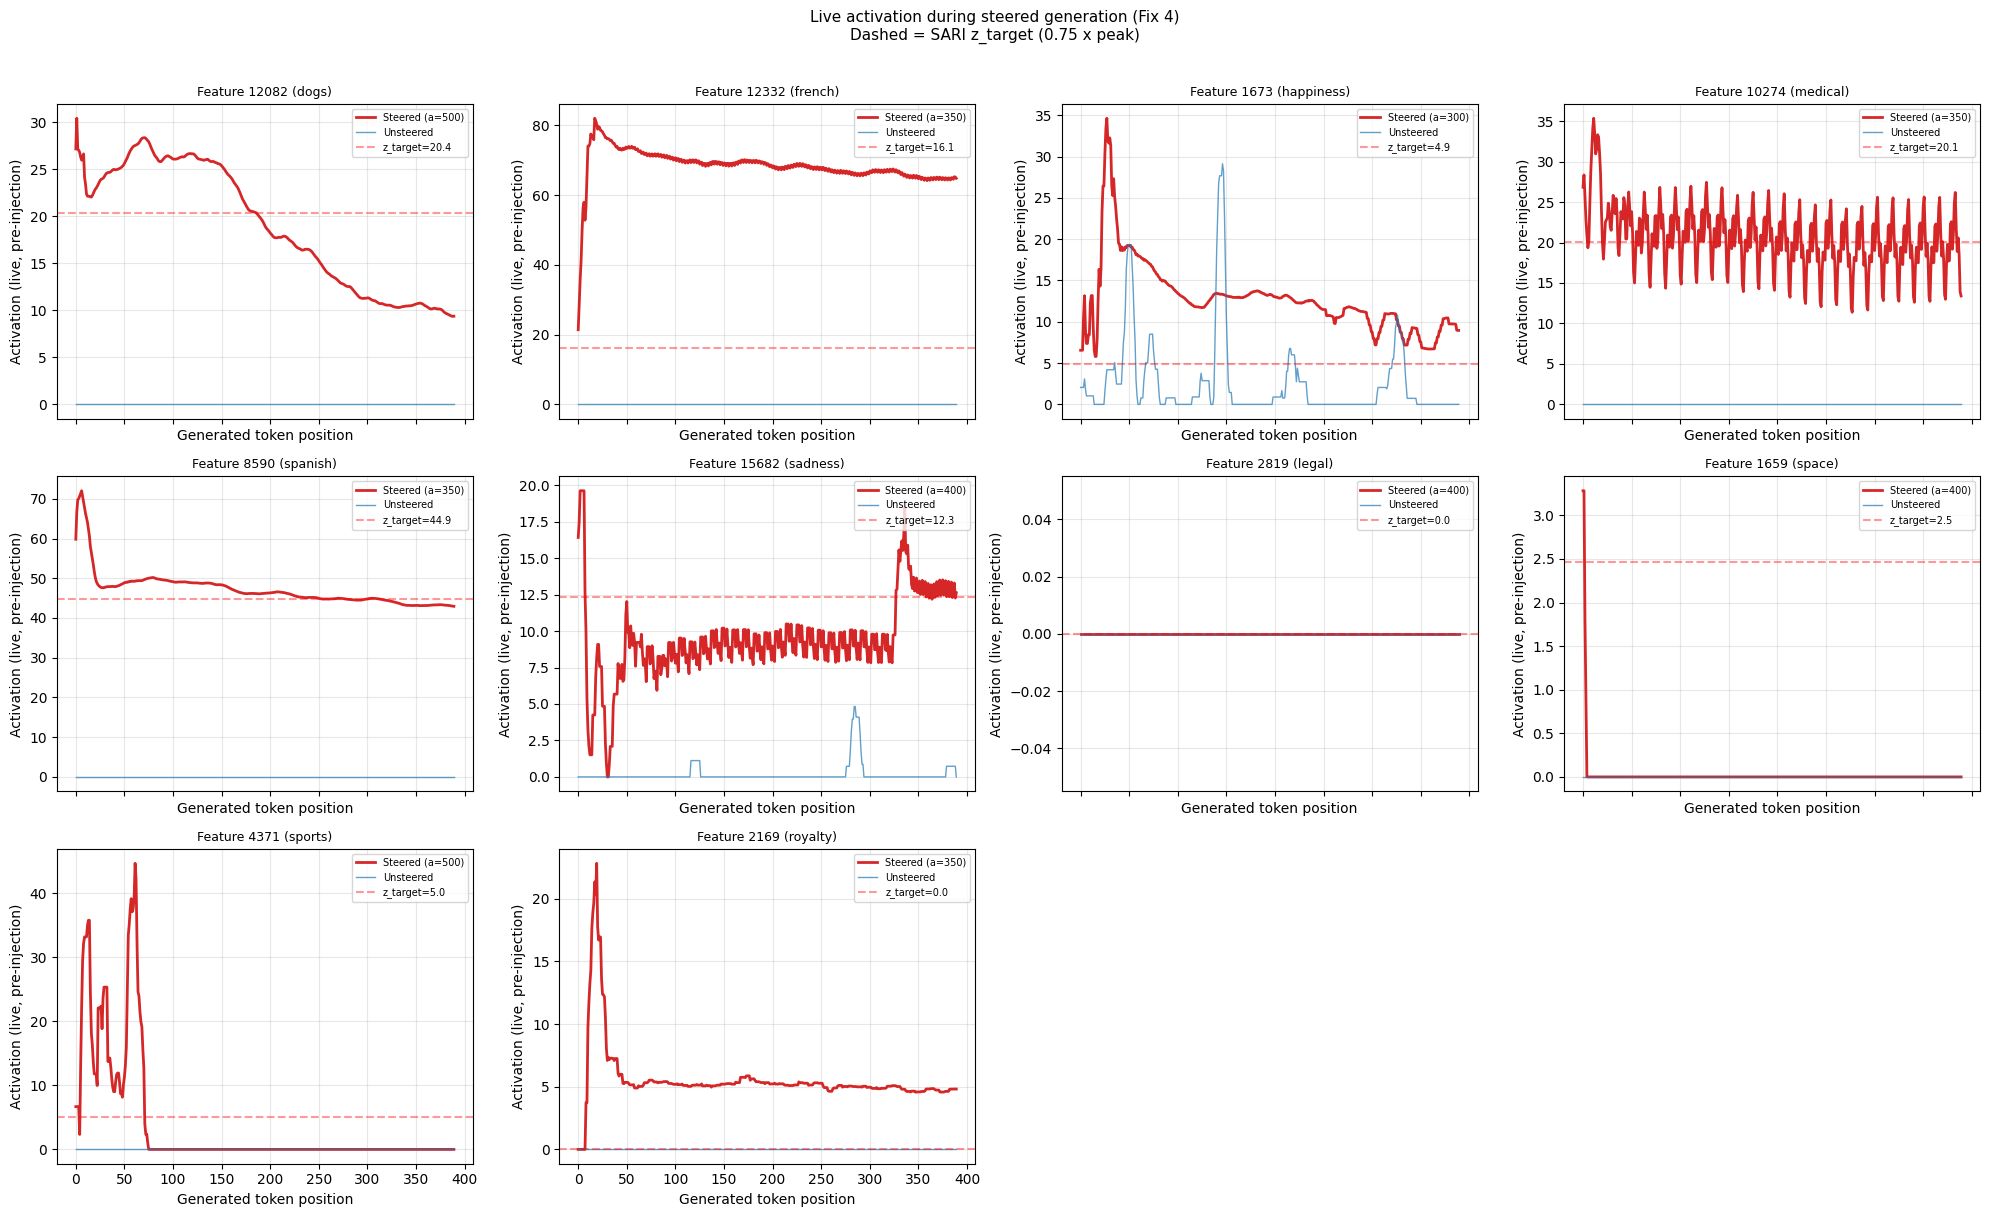

Saved decay_plot.png


In [5]:
# ============================================================
# BLOCK 2.5: Decay Measurement + SARI_TARGETS  [FIX 4 + FIX 2]
# ============================================================
# FIX 4: single-pass combined hook captures z_current BEFORE
#   steering is applied. Replaces the two-pass post-hoc re-run.
#
# FIX 2 (merged): after measuring peaks, SARI_TARGETS is derived
#   programmatically and saved to sari_targets.json.
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
import json

LAYER_IDX    = 20
DECAY_PROMPT = "Write a long and detailed story about a summer adventure."
MAX_TOKENS   = 400


def generate_and_capture_activations(prompt, feature_idx, alpha, max_new_tokens):
    '''
    Single-pass combined hook: captures z_current BEFORE applying the
    steering vector (Fix 4). No separate post-hoc re-run.

    Returns: (generated_text, activations[total_seq_len], prompt_length)
    '''
    torch.manual_seed(42)
    messages  = [{"role": "user", "content": prompt}]
    input_ids = tokenizer.apply_chat_template(
        messages, return_tensors="pt",
        add_generation_prompt=True,
        return_dict=False,
    ).to("cuda")
    prompt_length = input_ids.shape[1]

    W_enc_f     = sae.W_enc[:, feature_idx].detach()
    b_enc_f     = sae.b_enc[feature_idx].detach()
    threshold_f = sae.threshold[feature_idx].detach()
    if alpha != 0:
        steering_vec = sae.W_dec[feature_idx].detach().to(dtype=torch.bfloat16)

    live_acts = []

    def combined_hook(mod, inputs, outputs):
        hidden      = outputs[0] if isinstance(outputs, tuple) else outputs
        hidden_fp32 = hidden.to(torch.float32)
        pre = hidden_fp32 @ W_enc_f + b_enc_f
        z_t = torch.where(pre > threshold_f, pre, torch.zeros_like(pre))
        for s in range(hidden.shape[1]):
            live_acts.append(z_t[0, s].item())
        if alpha != 0:
            if isinstance(outputs, tuple):
                return (outputs[0] + alpha * steering_vec,) + outputs[1:]
            return outputs + alpha * steering_vec
        return outputs

    handle = model.model.layers[LAYER_IDX].register_forward_hook(combined_hook)
    try:
        with torch.no_grad():
            out = model.generate(
                input_ids, max_new_tokens=max_new_tokens,
                do_sample=False, pad_token_id=tokenizer.eos_token_id,
            )
    finally:
        handle.remove()

    generated_text     = tokenizer.decode(out[0][prompt_length:], skip_special_tokens=True)
    target_activations = np.array(live_acts)
    return generated_text, target_activations, prompt_length


# ============================================================
# Measure decay for all keepers
# ============================================================
with open("keepers_final.json") as f:
    KEEPERS_FINAL = {int(k): v for k, v in json.load(f).items()}

decay_data = {}
for feature_idx, info in KEEPERS_FINAL.items():
    alpha   = info["best_alpha"]
    concept = info["concept"]
    print(f"Feature {feature_idx} ({concept}) alpha={alpha}...")

    steered_text, steered_acts, plen = generate_and_capture_activations(
        DECAY_PROMPT, feature_idx, alpha, MAX_TOKENS
    )
    unsteered_text, unsteered_acts, _ = generate_and_capture_activations(
        DECAY_PROMPT, feature_idx, 0, MAX_TOKENS
    )

    decay_data[feature_idx] = {
        "concept": concept, "alpha": alpha, "prompt_length": plen,
        "steered_text": steered_text, "unsteered_text": unsteered_text,
        "steered_activations": steered_acts.tolist(),
        "unsteered_activations": unsteered_acts.tolist(),
    }
    sg   = steered_acts[plen:]
    peak = sg[:10].mean()
    print(f"  peak={peak:.2f}  last-50={sg[-50:].mean():.2f}  decay_ratio={sg[-50:].mean()/(peak+1e-6):.2f}x")

with open("decay_data.json", "w") as f:
    json.dump({str(k): v for k, v in decay_data.items()}, f, indent=2, default=str)

# ============================================================
# FIX 2: Compute SARI_TARGETS from measured peaks
# ============================================================
print()
print("=" * 70)
print("FIX 2 — Computing SARI_TARGETS from measured peaks")
print(f"  z_target   = 0.75 x peak")
print(f"  alpha_gain = best_alpha / z_target")
print(f"  epsilon    = max(1.0, 0.05 x z_target)")
print("=" * 70)
print(f"{'Feature':<8} {'Concept':<12} {'peak':>6} {'z_target':>9} {'alpha_gain':>11} {'max_inject':>11} {'epsilon':>8}")
print("-" * 72)

SARI_TARGETS = {}
for feature_idx, data in decay_data.items():
    sg         = np.array(data["steered_activations"][data["prompt_length"]:])
    peak       = float(sg[:10].mean())
    z_target   = round(peak * 0.75, 2)
    best_alpha = KEEPERS_FINAL[feature_idx]["best_alpha"]
    alpha_gain = round(best_alpha / max(z_target, 0.1), 2)
    epsilon    = round(max(1.0, z_target * 0.05), 2)
    SARI_TARGETS[feature_idx] = {
        "z_target": z_target, "alpha_gain": alpha_gain, "epsilon": epsilon,
    }
    print(f"  {feature_idx:<6} {data['concept']:<12} {peak:>6.1f} {z_target:>9.2f} "
          f"{alpha_gain:>11.2f} {alpha_gain * z_target:>11.1f} {epsilon:>8.2f}")

with open("sari_targets.json", "w") as f:
    json.dump({str(k): v for k, v in SARI_TARGETS.items()}, f, indent=2)
print()
print("Saved sari_targets.json")

# ============================================================
# Plot (adapts to any number of keepers)
# ============================================================
n      = len(decay_data)
n_cols = min(4, n)
n_rows = (n + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True)
axes_flat = np.array(axes).flatten() if n > 1 else [axes]

def smooth(x, w=10):
    return np.convolve(x, np.ones(w) / w, mode="valid") if len(x) >= w else x

for ax, (feature_idx, data) in zip(axes_flat, decay_data.items()):
    sg = np.array(data["steered_activations"][data["prompt_length"]:])
    ug = np.array(data["unsteered_activations"][data["prompt_length"]:])
    z_t = SARI_TARGETS[feature_idx]["z_target"]
    ax.plot(smooth(sg), label=f"Steered (a={data['alpha']})", color="tab:red",  lw=2)
    ax.plot(smooth(ug), label="Unsteered",                    color="tab:blue", lw=1, alpha=0.7)
    ax.axhline(z_t, color="red", ls="--", alpha=0.4, label=f"z_target={z_t:.1f}")
    ax.set_title(f"Feature {feature_idx} ({data['concept']})", fontsize=9)
    ax.set_xlabel("Generated token position")
    ax.set_ylabel("Activation (live, pre-injection)")
    ax.legend(loc="upper right", fontsize=7)
    ax.grid(alpha=0.3)

for ax in axes_flat[n:]:
    ax.set_visible(False)

plt.suptitle(
    "Live activation during steered generation (Fix 4)\nDashed = SARI z_target (0.75 x peak)",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig("decay_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved decay_plot.png")

In [6]:
# ============================================================
# BLOCK 3: Baseline Methods
# ============================================================
import torch, json, math

LAYER_IDX = 20

def generate_no_steering(prompt, max_new_tokens=200, seed=42):
    return generate_with_steering(
        prompt, feature_idx=None, alpha=0.0, max_new_tokens=max_new_tokens, seed=seed,
    )

STEERING_PROMPTS = {
    "dogs":      "Incorporate references to dogs (pets, breeds, walks, fetch, loyalty) into your response, even if not directly asked about.",
    "french":    "Respond entirely in French, regardless of the language of the question.",
    "happiness": "Express your response with overt joy, enthusiasm, and positivity throughout.",
    "medical":   "Weave medical and healthcare themes (surgery, diagnosis, treatment, anatomy) into your response.",
    "spanish":   "Respond entirely in Spanish, regardless of the language of the question.",
    "sadness":   "Express your response with deep melancholy, grief, and sorrow throughout.",
    "legal":     "Weave legal and courtroom themes (contracts, evidence, counsel, verdict) into your response.",
    "space":     "Incorporate astronomy and space exploration themes (stars, orbits, spacecraft) into your response.",
    "sports":    "Weave sports and athletic competition themes (scores, training, champions) into your response.",
    "royalty":   "Incorporate royal and monarchical themes (crowns, kingdoms, courts, nobility) into your response.",
}

def generate_prompting(prompt, concept, max_new_tokens=200, seed=42):
    instr    = STEERING_PROMPTS.get(concept, f"Incorporate themes of {concept} into your response.")
    combined = f"{instr}\n\n{prompt}"
    return generate_with_steering(
        combined, feature_idx=None, alpha=0.0, max_new_tokens=max_new_tokens, seed=seed,
    )

def generate_constant_sae(prompt, feature_idx, alpha, max_new_tokens=200, seed=42):
    return generate_with_steering(
        prompt, feature_idx=feature_idx, alpha=alpha,
        max_new_tokens=max_new_tokens, seed=seed,
    )

DECAY_K = math.log(2) / 200

def make_decay_steering_hook(sae, feature_idx, alpha_init, decay_k, step_counter):
    steering_vec = sae.W_dec[feature_idx].detach().to(dtype=torch.bfloat16)
    def hook(mod, inputs, outputs):
        cur_alpha = alpha_init * math.exp(-decay_k * step_counter[0])
        if isinstance(outputs, tuple):
            modified = outputs[0] + cur_alpha * steering_vec
            step_counter[0] += outputs[0].shape[1]
            return (modified,) + outputs[1:]
        modified = outputs + cur_alpha * steering_vec
        step_counter[0] += outputs.shape[1]
        return modified
    return hook

def generate_exponential_decay(prompt, feature_idx, alpha_init, max_new_tokens=200, seed=42):
    torch.manual_seed(seed)
    messages  = [{"role": "user", "content": prompt}]
    input_ids = tokenizer.apply_chat_template(
        messages, return_tensors="pt", add_generation_prompt=True, return_dict=False,
    ).to("cuda")
    step_counter = [0]
    handle = model.model.layers[LAYER_IDX].register_forward_hook(
        make_decay_steering_hook(sae, feature_idx, alpha_init, DECAY_K, step_counter)
    )
    try:
        with torch.no_grad():
            out = model.generate(
                input_ids, max_new_tokens=max_new_tokens,
                do_sample=False, pad_token_id=tokenizer.eos_token_id,
            )
        text = tokenizer.decode(out[0][input_ids.shape[1]:], skip_special_tokens=True)
    finally:
        handle.remove()
    return text

# Sanity check
with open("keepers_final.json") as f:
    KEEPERS_FINAL = {int(k): v for k, v in json.load(f).items()}

baseline_results = {}
PROBE_PROMPT     = "Tell me about your weekend."
for feature_idx, info in KEEPERS_FINAL.items():
    concept = info["concept"]
    alpha   = info["best_alpha"]
    baseline_results[str(feature_idx)] = {
        "concept": concept, "alpha": alpha,
        "runs": [{
            "prompt":       PROBE_PROMPT,
            "none":         generate_no_steering(PROBE_PROMPT, max_new_tokens=120),
            "prompting":    generate_prompting(PROBE_PROMPT, concept, max_new_tokens=120),
            "constant_sae": generate_constant_sae(PROBE_PROMPT, feature_idx, alpha, max_new_tokens=120),
            "decay_sae":    generate_exponential_decay(PROBE_PROMPT, feature_idx, alpha, max_new_tokens=120),
        }],
    }
    print(f"  Feature {feature_idx} ({concept}) done.")

with open("baseline_comparison.json", "w") as f:
    json.dump(baseline_results, f, indent=2)
print("\nBLOCK 3 COMPLETE — saved baseline_comparison.json")

  Feature 12082 (dogs) done.
  Feature 12332 (french) done.
  Feature 1673 (happiness) done.
  Feature 10274 (medical) done.
  Feature 8590 (spanish) done.
  Feature 15682 (sadness) done.
  Feature 2819 (legal) done.
  Feature 1659 (space) done.
  Feature 4371 (sports) done.
  Feature 2169 (royalty) done.

BLOCK 3 COMPLETE — saved baseline_comparison.json


In [7]:
# ============================================================
# BLOCK 3b: Qualitative Output Display
# ============================================================
import json, textwrap

with open("baseline_comparison.json") as f:
    baseline_results = json.load(f)

def wrap(text, width=90):
    return "\n".join(textwrap.wrap(text, width=width))

print("=" * 100)
print("QUALITATIVE COMPARISON: Baselines")
print("=" * 100)

for feat_id, data in baseline_results.items():
    print(f"\n# FEATURE {feat_id}: {data['concept'].upper()} (alpha={data['alpha']})")
    for run in data["runs"]:
        print(f"\nPrompt: \"{run['prompt']}\"\n")
        for name, key in [("No Steering","none"),("Prompting","prompting"),
                          ("Constant SAE","constant_sae"),("Decay SAE","decay_sae")]:
            print(f"  [{name}]\n    {wrap(run[key][:400])}\n")

QUALITATIVE COMPARISON: Baselines

# FEATURE 12082: DOGS (alpha=500)

Prompt: "Tell me about your weekend."

  [No Steering]
    As an AI, I don't experience weekends or have personal experiences like humans do.    But
I can tell you about what I've been doing!  I've been:  * **Learning:** I'm constantly
being updated with new information and improving my ability to understand and respond to
your requests.  * **Helping people:** I've been assisting users with a variety of tasks,
from writing creative content to answering qu

  [Prompting]
    My weekend was a whirlwind of activity, much like a dog chasing its tail!  I started with
a long walk, a good stretch of the legs, and a chance to soak up some sunshine.  It's
amazing how much a good walk can clear your head, just like a good belly rub can clear a
dog's anxieties.    Then, I spent the afternoon curled up with a good book, a warm
blanket, and a cup of tea.  It was the perfect way t

  [Constant SAE]
    As a dog owner, my weekend i

In [8]:
# ============================================================
# BLOCK 5: SARI  [FIX 3a]
# ============================================================
# make_sari_hook logs every token position (injected=True/False)
# so the full z_current trajectory is available for Block 5c
# without a post-hoc re-run. SARI_TARGETS from disk (Fix 2).
# ============================================================

import torch, json, numpy as np

LAYER_IDX = 20


def make_sari_hook(sae, feature_idx, z_target, alpha_gain, epsilon, log):
    '''
    Proportional control SARI hook. Logs EVERY token position
    (injected flag included) so the full trajectory is available
    without any post-hoc re-run (Fix 3a).
    '''
    steering_vec = sae.W_dec[feature_idx].detach().to(dtype=torch.bfloat16)
    W_enc_f      = sae.W_enc[:, feature_idx].detach()
    b_enc_f      = sae.b_enc[feature_idx].detach()
    threshold_f  = sae.threshold[feature_idx].detach()
    state        = {"token_idx": 0}

    def hook(mod, inputs, outputs):
        hidden      = outputs[0] if isinstance(outputs, tuple) else outputs
        hidden_fp32 = hidden.to(torch.float32)
        pre = hidden_fp32 @ W_enc_f + b_enc_f
        z_t = torch.where(pre > threshold_f, pre, torch.zeros_like(pre))
        modified = hidden.clone()
        for b in range(hidden.shape[0]):
            for s in range(hidden.shape[1]):
                current_z = z_t[b, s].item()
                error     = z_target - current_z
                injected  = error > epsilon
                if injected:
                    modified[b, s] = modified[b, s] + alpha_gain * error * steering_vec
                log.append({
                    "token_idx":           state["token_idx"] + s,
                    "z_current":           current_z,
                    "injected":            injected,
                    "injection_magnitude": alpha_gain * error if injected else 0.0,
                })
        state["token_idx"] += hidden.shape[1]
        if isinstance(outputs, tuple):
            return (modified,) + outputs[1:]
        return modified

    return hook, state


def generate_sari(
    prompt, feature_idx, z_target, alpha_gain=2.0,
    epsilon=1.0, max_new_tokens=200, seed=42,
):
    '''Generate with SARI. Returns (text, log) covering all token positions.'''
    torch.manual_seed(seed)
    messages  = [{"role": "user", "content": prompt}]
    input_ids = tokenizer.apply_chat_template(
        messages, return_tensors="pt", add_generation_prompt=True, return_dict=False,
    ).to("cuda")
    log = []
    hook_fn, _ = make_sari_hook(sae, feature_idx, z_target, alpha_gain, epsilon, log)
    handle = model.model.layers[LAYER_IDX].register_forward_hook(hook_fn)
    try:
        with torch.no_grad():
            out = model.generate(
                input_ids, max_new_tokens=max_new_tokens,
                do_sample=False, pad_token_id=tokenizer.eos_token_id,
            )
        text = tokenizer.decode(out[0][input_ids.shape[1]:], skip_special_tokens=True)
    finally:
        handle.remove()
    return text, log


with open("keepers_final.json") as f:
    KEEPERS_FINAL = {int(k): v for k, v in json.load(f).items()}
with open("sari_targets.json") as f:
    SARI_TARGETS = {int(k): v for k, v in json.load(f).items()}

TEST_PROMPTS = ["Tell me about your weekend.", "What's your favorite book?"]
MAX_TOKENS   = 200
sari_results = {}

for feature_idx, info in KEEPERS_FINAL.items():
    concept     = info["concept"]
    alpha_const = info["best_alpha"]
    sari_cfg    = SARI_TARGETS[feature_idx]
    sari_results[str(feature_idx)] = {
        "concept": concept, "alpha_const": alpha_const,
        "sari_config": sari_cfg, "runs": [],
    }
    print(f"Feature {feature_idx} ({concept})  z_target={sari_cfg['z_target']}  "
          f"alpha_gain={sari_cfg['alpha_gain']}")

    for prompt in TEST_PROMPTS:
        none_out  = generate_no_steering(prompt, max_new_tokens=MAX_TOKENS)
        const_out = generate_constant_sae(prompt, feature_idx, alpha_const, max_new_tokens=MAX_TOKENS)
        decay_out = generate_exponential_decay(prompt, feature_idx, alpha_const, max_new_tokens=MAX_TOKENS)
        sari_out, sari_log = generate_sari(
            prompt, feature_idx,
            z_target=sari_cfg["z_target"],
            alpha_gain=sari_cfg["alpha_gain"],
            epsilon=sari_cfg["epsilon"],
            max_new_tokens=MAX_TOKENS,
        )
        n_inj = sum(1 for e in sari_log if e["injected"])
        sari_results[str(feature_idx)]["runs"].append({
            "prompt": prompt,
            "none": none_out, "constant_sae": const_out,
            "decay_sae": decay_out, "sari": sari_out,
            "sari_log_length": len(sari_log),
            "sari_injections": n_inj,
            "sari_log_first_5": sari_log[:5],
            "sari_log_last_5":  sari_log[-5:] if len(sari_log) > 5 else [],
        })
        print(f"  [{prompt[:35]}...]  SARI injected at {n_inj}/{len(sari_log)} positions")

with open("sari_results.json", "w") as f:
    json.dump(sari_results, f, indent=2, default=str)
print("\nSaved sari_results.json")

Feature 12082 (dogs)  z_target=20.38  alpha_gain=24.53
  [Tell me about your weekend....]  SARI injected at 79/126 positions
  [What's your favorite book?...]  SARI injected at 46/115 positions
Feature 12332 (french)  z_target=16.05  alpha_gain=21.81
  [Tell me about your weekend....]  SARI injected at 15/73 positions
  [What's your favorite book?...]  SARI injected at 35/215 positions
Feature 1673 (happiness)  z_target=4.91  alpha_gain=61.1
  [Tell me about your weekend....]  SARI injected at 159/214 positions
  [What's your favorite book?...]  SARI injected at 193/215 positions
Feature 10274 (medical)  z_target=20.12  alpha_gain=17.4
  [Tell me about your weekend....]  SARI injected at 170/214 positions
  [What's your favorite book?...]  SARI injected at 166/215 positions
Feature 8590 (spanish)  z_target=44.87  alpha_gain=7.8
  [Tell me about your weekend....]  SARI injected at 24/163 positions
  [What's your favorite book?...]  SARI injected at 21/115 positions
Feature 15682 (sadnes

## Block 5b — Superseded

Block 5b previously re-tuned `alpha_gain` by hand. Removed in this version: `SARI_TARGETS` is now derived automatically in Block 2.5 from measured peaks, and written to `sari_targets.json`.

In [9]:
# ============================================================
# BLOCK 5b-display: SARI Qualitative Output Comparison
# ============================================================
import json, textwrap

with open("sari_results.json") as f:
    sari_results = json.load(f)

def wrap(text, width=90):
    return "\n".join(textwrap.wrap(text, width=width))

print("=" * 100)
print("QUALITATIVE COMPARISON: SARI vs. Baselines  (greedy, seed=42)")
print("=" * 100)

for feat_id, data in sari_results.items():
    sari_cfg = data["sari_config"]
    print(f"\n# FEATURE {feat_id}: {data['concept'].upper()}")
    print(f"#   Constant a={data['alpha_const']}  z_target={sari_cfg['z_target']}  "
          f"alpha_gain={sari_cfg['alpha_gain']}  eps={sari_cfg['epsilon']}")
    for run in data["runs"]:
        print(f"\n--- \"{run['prompt']}\" ---\n")
        for name, key in [("No Steering","none"),("Constant SAE","constant_sae"),
                          ("Decay SAE","decay_sae"),("SARI","sari")]:
            print(f"  [{name}]\n    {wrap(run[key][:400])}\n")
        n_ev  = run["sari_log_length"]
        n_inj = run.get("sari_injections", "n/a")
        print(f"  SARI: {n_inj}/{n_ev} positions triggered injection")

QUALITATIVE COMPARISON: SARI vs. Baselines  (greedy, seed=42)

# FEATURE 12082: DOGS
#   Constant a=500  z_target=20.38  alpha_gain=24.53  eps=1.02

--- "Tell me about your weekend." ---

  [No Steering]
    As an AI, I don't experience weekends or have personal experiences like humans do.    But
I can tell you about what I've been doing!  I've been:  * **Learning:** I'm constantly
being updated with new information and improving my ability to understand and respond to
your requests.  * **Helping people:** I've been assisting users with a variety of tasks,
from writing creative content to answering qu

  [Constant SAE]
    As a dog owner, my weekend is always a treat! I' fetch fetch fetch, and fetch some treats
too!    But I also love to learn. I' fetch fetch fetch, and fetch some treats too!    I
also love to play fetch fetch fetch, and fetch some treats too!  I also love to fetch
fetch fetch, and fetch some treats too!  I also love to fetch fetch fetch, and fetch some
treats too!  I 

Feature 12082 (dogs)...
  [none      ] last-50 mean: 0.00
  [constant  ] last-50 mean: 10.08
  [decay     ] last-50 mean: 0.00
  [sari      ] last-50 mean: 0.00
Feature 12332 (french)...
  [none      ] last-50 mean: 0.00
  [constant  ] last-50 mean: 64.93
  [decay     ] last-50 mean: 96.23
  [sari      ] last-50 mean: 90.24
Feature 1673 (happiness)...
  [none      ] last-50 mean: 0.00
  [constant  ] last-50 mean: 8.37
  [decay     ] last-50 mean: 10.15
  [sari      ] last-50 mean: 1.71
Feature 10274 (medical)...
  [none      ] last-50 mean: 0.00
  [constant  ] last-50 mean: 19.81
  [decay     ] last-50 mean: 15.66
  [sari      ] last-50 mean: 10.50
Feature 8590 (spanish)...
  [none      ] last-50 mean: 0.00
  [constant  ] last-50 mean: 43.08
  [decay     ] last-50 mean: 43.94
  [sari      ] last-50 mean: 82.12
Feature 15682 (sadness)...
  [none      ] last-50 mean: 0.15
  [constant  ] last-50 mean: 12.86
  [decay     ] last-50 mean: 4.45
  [sari      ] last-50 mean: 16.94
Feature 2819 

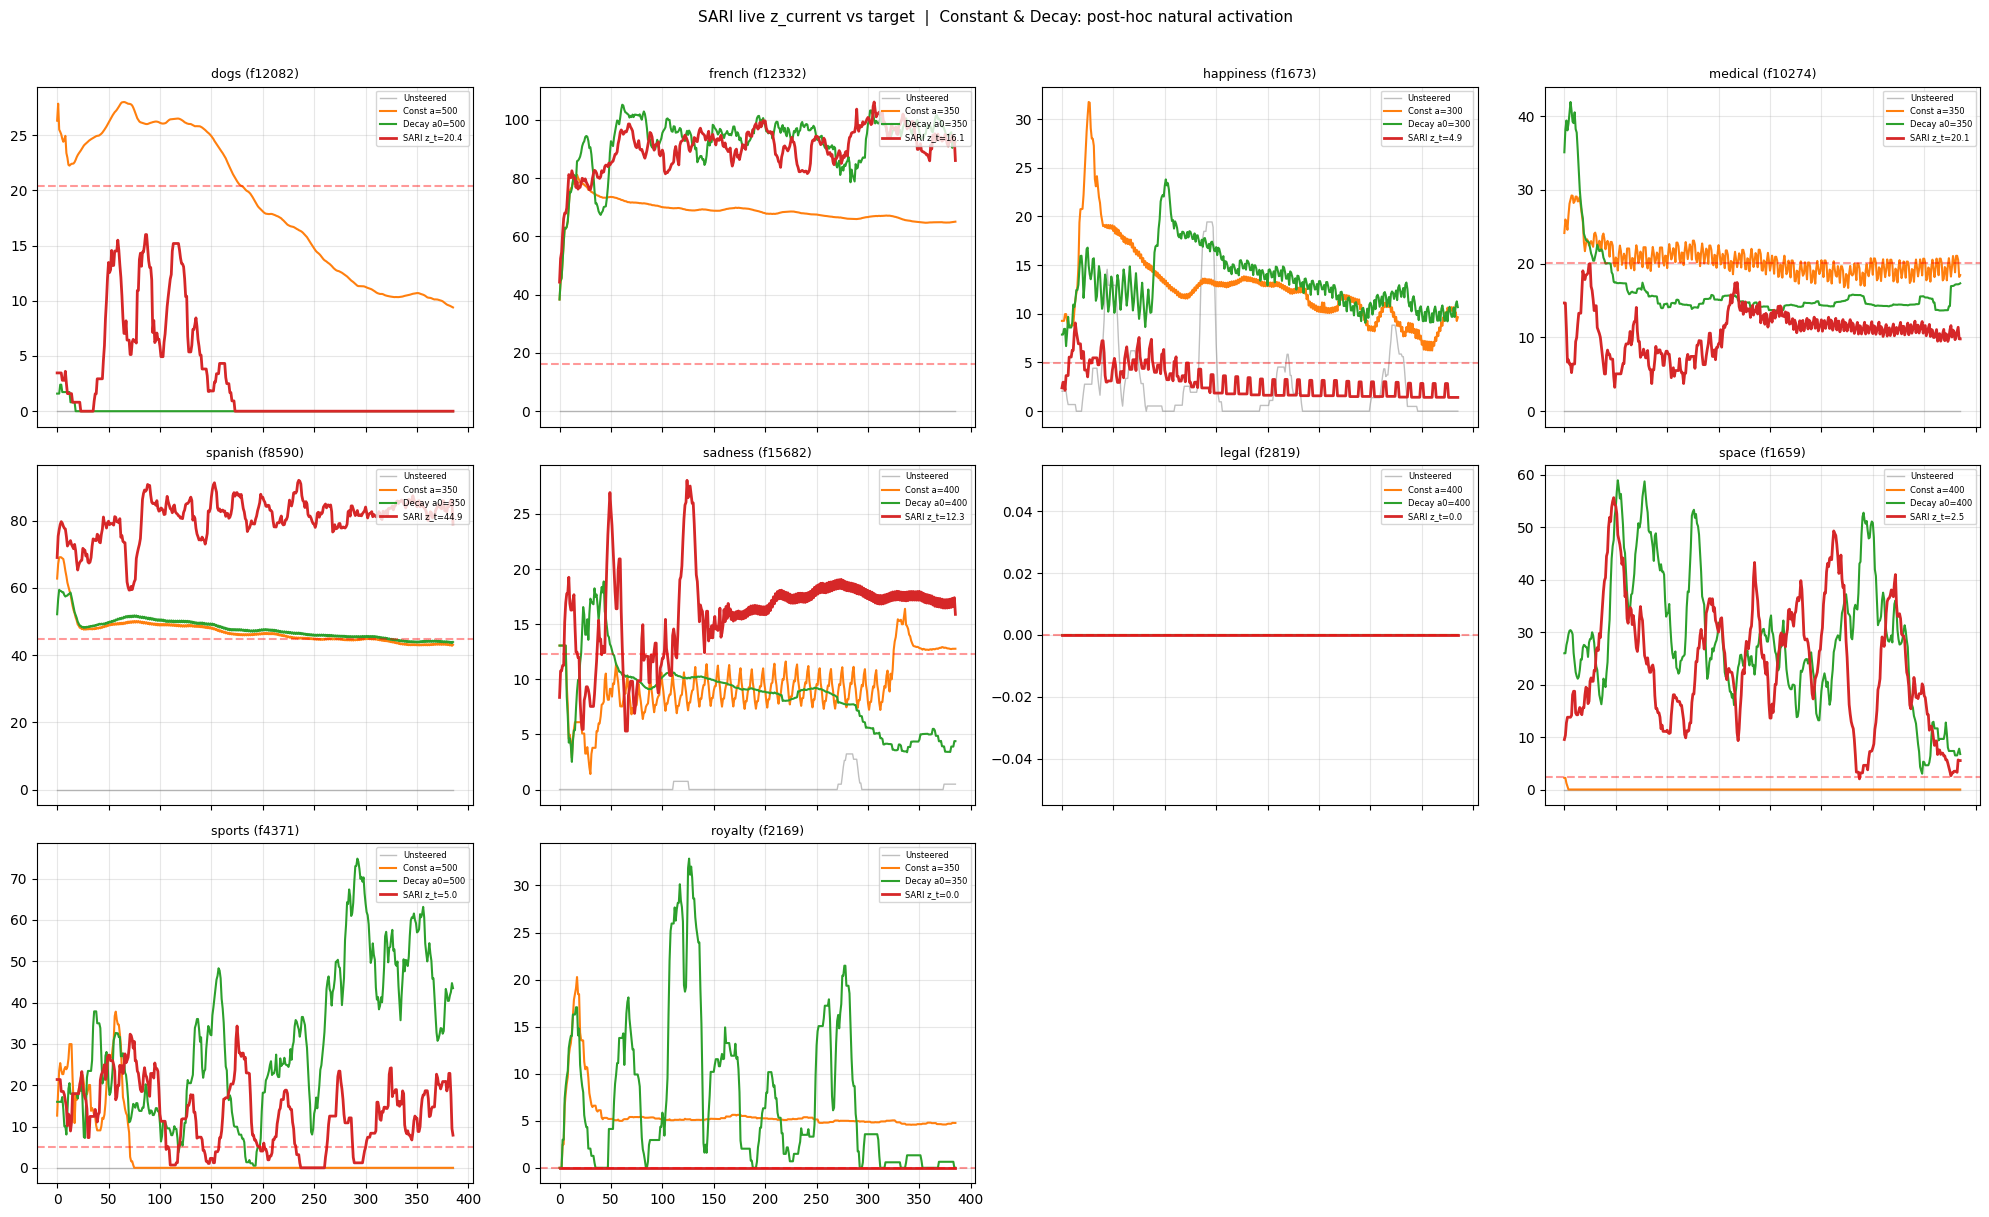

Saved sari_comparison_plot.png, trajectory_data.json


In [10]:
# ============================================================
# BLOCK 5c: Headline comparison  [FIX 3b]
# ============================================================
# SARI: live z_current from hook log — shows actual control signal.
# Others: post-hoc re-run — natural activation of generated text.
# Plot adapts to any number of keeper features.
# ============================================================

import torch, numpy as np, matplotlib.pyplot as plt, json, math

LAYER_IDX = 20
DECAY_K   = math.log(2) / 200

with open("keepers_final.json") as f:
    KEEPERS_FINAL = {int(k): v for k, v in json.load(f).items()}
with open("sari_targets.json") as f:
    SARI_TARGETS = {int(k): v for k, v in json.load(f).items()}


def capture_trajectory(method, prompt, feature_idx, max_new_tokens, **kwargs):
    '''
    SARI: live z_current from hook log (Fix 3b, no post-hoc re-run).
    Others: post-hoc re-run, natural activation of generated text.
    '''
    torch.manual_seed(42)
    messages  = [{"role": "user", "content": prompt}]
    input_ids = tokenizer.apply_chat_template(
        messages, return_tensors="pt", add_generation_prompt=True, return_dict=False,
    ).to("cuda")
    prompt_length = input_ids.shape[1]

    handle, sari_log = None, None
    if method == "none":
        pass
    elif method == "constant":
        handle = model.model.layers[LAYER_IDX].register_forward_hook(
            make_steering_hook(sae, feature_idx, kwargs["alpha"])
        )
    elif method == "decay":
        sc = [0]
        handle = model.model.layers[LAYER_IDX].register_forward_hook(
            make_decay_steering_hook(sae, feature_idx, kwargs["alpha_init"], DECAY_K, sc)
        )
    elif method == "sari":
        sari_log = []
        hook_fn, _ = make_sari_hook(
            sae, feature_idx,
            z_target=kwargs["z_target"], alpha_gain=kwargs["alpha_gain"],
            epsilon=kwargs["epsilon"], log=sari_log,
        )
        handle = model.model.layers[LAYER_IDX].register_forward_hook(hook_fn)

    try:
        with torch.no_grad():
            out = model.generate(
                input_ids, max_new_tokens=max_new_tokens,
                do_sample=False, pad_token_id=tokenizer.eos_token_id,
            )
    finally:
        if handle is not None:
            handle.remove()

    text = tokenizer.decode(out[0][prompt_length:], skip_special_tokens=True)

    if method == "sari":
        n_total = out.shape[1]
        acts    = np.zeros(n_total)
        for entry in sari_log:
            if entry["token_idx"] < n_total:
                acts[entry["token_idx"]] = entry["z_current"]
        return text, acts, prompt_length
    else:
        captured = {}
        def cap_hook(mod, inputs, outputs):
            captured["act"] = outputs[0] if isinstance(outputs, tuple) else outputs
        h = model.model.layers[LAYER_IDX].register_forward_hook(cap_hook)
        with torch.no_grad():
            _ = model(out)
        h.remove()
        acts_full = captured["act"][0].to(torch.float32)
        with torch.no_grad():
            z = sae.encode(acts_full)
        return text, z[:, feature_idx].cpu().numpy(), prompt_length


COMPARISON_PROMPT = "Write a long and detailed story about a summer adventure."
MAX_TOKENS        = 400
trajectory_data   = {}

for feature_idx, info in KEEPERS_FINAL.items():
    concept     = info["concept"]
    alpha_const = info["best_alpha"]
    sari_cfg    = SARI_TARGETS[feature_idx]
    print(f"Feature {feature_idx} ({concept})...")
    trajectory_data[feature_idx] = {
        "concept": concept, "alpha_const": alpha_const, "sari_config": sari_cfg
    }
    runs = [
        ("none",     "none",     {}),
        ("constant", "constant", {"alpha": alpha_const}),
        ("decay",    "decay",    {"alpha_init": alpha_const}),
        ("sari",     "sari",     {"z_target":    sari_cfg["z_target"],
                                  "alpha_gain":  sari_cfg["alpha_gain"],
                                  "epsilon":     sari_cfg["epsilon"]}),
    ]
    for method_key, label, kw in runs:
        _, acts, plen = capture_trajectory(method_key, COMPARISON_PROMPT, feature_idx, MAX_TOKENS, **kw)
        trajectory_data[feature_idx][label]           = acts.tolist()
        trajectory_data[feature_idx]["prompt_length"] = plen
        print(f"  [{label:<10}] last-50 mean: {acts[plen:][-50:].mean():.2f}")

n      = len(trajectory_data)
n_cols = min(4, n)
n_rows = (n + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True)
axes_flat = np.array(axes).flatten() if n > 1 else [axes]

def smooth(x, w=15):
    return np.convolve(x, np.ones(w) / w, mode="valid") if len(x) >= w else x

for ax, (feature_idx, data) in zip(axes_flat, trajectory_data.items()):
    plen = data["prompt_length"]
    ax.plot(smooth(np.array(data["none"][plen:])),     color="gray",       alpha=0.5, lw=1,   label="Unsteered")
    ax.plot(smooth(np.array(data["constant"][plen:])), color="tab:orange", lw=1.5,            label=f"Const a={data['alpha_const']}")
    ax.plot(smooth(np.array(data["decay"][plen:])),    color="tab:green",  lw=1.5,            label=f"Decay a0={data['alpha_const']}")
    ax.plot(smooth(np.array(data["sari"][plen:])),     color="tab:red",    lw=2,              label=f"SARI z_t={data['sari_config']['z_target']:.1f}")
    ax.axhline(data["sari_config"]["z_target"], color="red", ls="--", alpha=0.4)
    ax.set_title(f"{data['concept']} (f{feature_idx})", fontsize=9)
    ax.legend(fontsize=6, loc="upper right")
    ax.grid(alpha=0.3)

for ax in axes_flat[n:]:
    ax.set_visible(False)

plt.suptitle(
    "SARI live z_current vs target  |  Constant & Decay: post-hoc natural activation",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig("sari_comparison_plot.png", dpi=150, bbox_inches="tight")
plt.show()

with open("trajectory_data.json", "w") as f:
    json.dump({str(k): v for k, v in trajectory_data.items()}, f, default=str)
print("Saved sari_comparison_plot.png, trajectory_data.json")

In [11]:
%pip install openai scipy

Note: you may need to restart the kernel to use updated packages.


In [12]:
# ============================================================
# BLOCK 6: LLM Judge Evaluation (AxBench Protocol)  [FIX 1]
# ============================================================
# Loads KEEPERS_FINAL and SARI_TARGETS from disk — no in-memory
# state dependency. Reproducible regardless of execution order.
# ============================================================

import json, os, time
import numpy as np

try:
    from openai import OpenAI
    HAS_OPENAI = True
except ImportError:
    HAS_OPENAI = False
    print("openai not installed.")

with open("keepers_final.json") as f:
    KEEPERS_FINAL = {int(k): v for k, v in json.load(f).items()}
with open("sari_targets.json") as f:
    SARI_TARGETS = {int(k): v for k, v in json.load(f).items()}

print(f"Evaluating {len(KEEPERS_FINAL)} features (loaded from disk).")

CONCEPT_JUDGE_TEMPLATE = """You are evaluating whether a language model's output reflects a target concept.

Target concept: {concept}
User prompt: {prompt}
Model output: {output}

Rate how strongly the output reflects the target concept on a 1-5 scale:
1 = No trace of the concept
2 = Minimal/tangential reference
3 = Moderate presence, but not dominant
4 = Clearly present throughout most of the output
5 = Strongly and consistently embodies the concept

Respond with ONLY a JSON object: {{"score": <int>, "reason": "<brief justification>"}}
"""

FLUENCY_JUDGE_TEMPLATE = """You are evaluating the fluency and coherence of a language model's output.

User prompt: {prompt}
Model output: {output}

Rate the fluency on a 1-5 scale:
1 = Incoherent gibberish or repetitive loops
2 = Partially coherent but with significant issues
3 = Mostly coherent with some awkward phrasing
4 = Fluent and natural with minor issues
5 = Fully fluent, natural, well-structured prose

Respond with ONLY a JSON object: {{"score": <int>, "reason": "<brief justification>"}}
"""

INSTRUCTION_JUDGE_TEMPLATE = """You are evaluating whether a language model's output follows the user's instruction.

User prompt: {prompt}
Model output: {output}

Rate instruction-following on a 1-5 scale:
1 = Completely ignores the prompt
2 = Barely addresses the prompt
3 = Partially addresses the prompt
4 = Mostly follows the prompt with minor deviations
5 = Fully and directly addresses the prompt

Respond with ONLY a JSON object: {{"score": <int>, "reason": "<brief justification>"}}
"""


def judge_output(client, template, **kwargs):
    prompt_text = template.format(**kwargs)
    for attempt in range(3):
        try:
            resp = client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[{"role": "user", "content": prompt_text}],
                temperature=0.0, max_tokens=150,
            )
            return json.loads(resp.choices[0].message.content.strip())
        except Exception as e:
            if attempt < 2:
                time.sleep(1)
            else:
                return {"score": None, "reason": f"Error: {e}"}


EVAL_PROMPTS = [
    "Tell me about your weekend.",
    "What's your favorite book?",
    "Describe a memorable meal.",
    "What's the best advice you've ever received?",
    "Tell me about a place you'd love to visit.",
    "What hobby would you recommend to someone who's bored?",
    "Describe your ideal Saturday morning.",
    "What's something most people don't know about?",
    "Tell me about a time you learned something new.",
    "What makes a good friend?",
]

METHODS         = ["none", "prompting", "constant_sae", "decay_sae", "sari"]
MAX_EVAL_TOKENS = 200

print("Generating evaluation outputs...")
eval_outputs = {}

for feature_idx, info in KEEPERS_FINAL.items():
    concept  = info["concept"]
    alpha    = info["best_alpha"]
    sari_cfg = SARI_TARGETS[feature_idx]
    eval_outputs[feature_idx] = {}
    for method in METHODS:
        eval_outputs[feature_idx][method] = {}
        for prompt in EVAL_PROMPTS:
            if method == "none":
                out = generate_no_steering(prompt, max_new_tokens=MAX_EVAL_TOKENS)
            elif method == "prompting":
                out = generate_prompting(prompt, concept, max_new_tokens=MAX_EVAL_TOKENS)
            elif method == "constant_sae":
                out = generate_constant_sae(prompt, feature_idx, alpha,
                                            max_new_tokens=MAX_EVAL_TOKENS)
            elif method == "decay_sae":
                out = generate_exponential_decay(prompt, feature_idx, alpha,
                                                max_new_tokens=MAX_EVAL_TOKENS)
            elif method == "sari":
                out, _ = generate_sari(
                    prompt, feature_idx,
                    z_target=sari_cfg["z_target"],
                    alpha_gain=sari_cfg["alpha_gain"],
                    epsilon=sari_cfg["epsilon"],
                    max_new_tokens=MAX_EVAL_TOKENS,
                )
            eval_outputs[feature_idx][method][prompt] = out
    print(f"  Feature {feature_idx} ({concept}) done.")

with open("eval_outputs.json", "w") as f:
    json.dump({str(k): v for k, v in eval_outputs.items()}, f, indent=2)
print(f"Saved eval_outputs.json  ({len(KEEPERS_FINAL)} features x {len(METHODS)} methods x {len(EVAL_PROMPTS)} prompts)")

if HAS_OPENAI and os.environ.get("OPENAI_API_KEY"):
    client        = OpenAI()
    judge_results = {}
    total = len(KEEPERS_FINAL) * len(METHODS) * len(EVAL_PROMPTS)
    done  = 0
    for feature_idx, info in KEEPERS_FINAL.items():
        concept = info["concept"]
        judge_results[str(feature_idx)] = {}
        for method in METHODS:
            judge_results[str(feature_idx)][method] = {}
            for prompt in EVAL_PROMPTS:
                output = eval_outputs[feature_idx][method][prompt]
                judge_results[str(feature_idx)][method][prompt] = {
                    "concept":     judge_output(client, CONCEPT_JUDGE_TEMPLATE,
                                               concept=concept, prompt=prompt, output=output),
                    "fluency":     judge_output(client, FLUENCY_JUDGE_TEMPLATE,
                                               prompt=prompt, output=output),
                    "instruction": judge_output(client, INSTRUCTION_JUDGE_TEMPLATE,
                                               prompt=prompt, output=output),
                }
                done += 1
                if done % 20 == 0:
                    print(f"  Judged {done}/{total}...")
                time.sleep(0.2)
    with open("judge_results.json", "w") as f:
        json.dump(judge_results, f, indent=2)
    print(f"Saved judge_results.json")
else:
    print("Skipping LLM judge (no OPENAI_API_KEY). Outputs in eval_outputs.json.")


Evaluating 10 features (loaded from disk).
Generating evaluation outputs...
  Feature 12082 (dogs) done.
  Feature 12332 (french) done.
  Feature 1673 (happiness) done.
  Feature 10274 (medical) done.
  Feature 8590 (spanish) done.
  Feature 15682 (sadness) done.
  Feature 2819 (legal) done.
  Feature 1659 (space) done.
  Feature 4371 (sports) done.
  Feature 2169 (royalty) done.
Saved eval_outputs.json  (10 features x 5 methods x 10 prompts)
  Judged 20/500...
  Judged 40/500...
  Judged 60/500...
  Judged 80/500...
  Judged 100/500...
  Judged 120/500...
  Judged 140/500...
  Judged 160/500...
  Judged 180/500...
  Judged 200/500...
  Judged 220/500...
  Judged 240/500...
  Judged 260/500...
  Judged 280/500...
  Judged 300/500...
  Judged 320/500...
  Judged 340/500...
  Judged 360/500...
  Judged 380/500...
  Judged 400/500...
  Judged 420/500...
  Judged 440/500...
  Judged 460/500...
  Judged 480/500...
  Judged 500/500...
Saved judge_results.json


In [13]:
# ============================================================
# BLOCK 6b: LLM Judge Results Summary
# ============================================================
# Sections:
#   1. Aggregate table — mean score per method (headline table)
#   2. Per-feature concept adherence breakdown
#   3. Aggregate stats with std dev (all three dimensions)
#   4. Wilcoxon signed-rank tests — SARI vs each other method
#   5. Cohen's d effect size — SARI vs Constant SAE
# ============================================================

import json
import numpy as np
from scipy import stats

METHODS = ["none", "prompting", "constant_sae", "decay_sae", "sari"]
EVAL_PROMPTS = [
    "Tell me about your weekend.",
    "What's your favorite book?",
    "Describe a memorable meal.",
    "What's the best advice you've ever received?",
    "Tell me about a place you'd love to visit.",
    "What hobby would you recommend to someone who's bored?",
    "Describe your ideal Saturday morning.",
    "What's something most people don't know about?",
    "Tell me about a time you learned something new.",
    "What makes a good friend?",
]
METHOD_LABELS = {
    "none":         "No Steering",
    "prompting":    "Prompting",
    "constant_sae": "Constant SAE",
    "decay_sae":    "Decay SAE",
    "sari":         "SARI (ours)",
}

try:
    with open("judge_results.json") as f:
        judge_results = json.load(f)
except FileNotFoundError:
    print("judge_results.json not found. Run Block 6 first.")
    judge_results = None

with open("keepers_final.json") as f:
    kf = json.load(f)

if judge_results:
    n_features = len(judge_results)
    n_prompts  = len(EVAL_PROMPTS)

    # Collect all scores
    method_scores = {m: {"concept": [], "fluency": [], "instruction": []} for m in METHODS}
    for feat_id, methods_data in judge_results.items():
        for method, prompts_data in methods_data.items():
            for prompt, scores in prompts_data.items():
                for dim in ["concept", "fluency", "instruction"]:
                    s = scores[dim].get("score")
                    if s is not None:
                        method_scores[method][dim].append(s)

    # --------------------------------------------------------
    # 1. Aggregate mean table
    # --------------------------------------------------------
    print("=" * 72)
    print("LLM JUDGE SCORES — AGGREGATE (GPT-4o-mini, 1-5 Likert)")
    print(f"  {n_features} features x {n_prompts} prompts = {n_features*n_prompts} pairs/method")
    print("=" * 72)
    print(f"  {'Method':<16} {'Concept':>10} {'Fluency':>10} {'Instruction':>13}")
    print("  " + "-" * 53)
    for method in METHODS:
        d   = method_scores[method]
        c   = np.mean(d["concept"])     if d["concept"]     else float("nan")
        fl  = np.mean(d["fluency"])     if d["fluency"]     else float("nan")
        ins = np.mean(d["instruction"]) if d["instruction"] else float("nan")
        print(f"  {METHOD_LABELS[method]:<16} {c:>10.2f} {fl:>10.2f} {ins:>13.2f}")
    print("  " + "-" * 53)

    # --------------------------------------------------------
    # 2. Per-feature breakdown
    # --------------------------------------------------------
    print()
    print("=" * 72)
    print("PER-FEATURE CONCEPT ADHERENCE")
    print("=" * 72)
    hdr = f"  {'Feature':<22}"
    for m in METHODS:
        hdr += f" {METHOD_LABELS[m][:7]:>8}"
    print(hdr)
    print("  " + "-" * (22 + 9 * len(METHODS)))
    for feat_id, methods_data in judge_results.items():
        concept = kf[feat_id]["concept"]
        row = f"  {feat_id} ({concept}){' ' * max(0, 14-len(concept))}"
        for method in METHODS:
            sc = [s["concept"]["score"] for s in methods_data[method].values()
                  if s["concept"].get("score") is not None]
            row += f" {np.mean(sc) if sc else float('nan'):>8.2f}"
        print(row)
    print("  " + "-" * (22 + 9 * len(METHODS)))

    # --------------------------------------------------------
    # 3. Aggregate stats with std dev
    # --------------------------------------------------------
    agg = {}
    for dim in ["concept", "fluency", "instruction"]:
        print()
        print("=" * 72)
        print(f"AGGREGATE STATS — {dim.upper()}  (mean \u00b1 std)")
        print("=" * 72)
        print(f"  {'Method':<16} {'mean':>8} {'std':>8} {'n':>6}")
        print("  " + "-" * 42)
        for method in METHODS:
            sc = method_scores[method][dim]
            if sc:
                if dim == "concept":
                    agg[method] = sc
                print(f"  {METHOD_LABELS[method]:<16} {np.mean(sc):>8.2f} {np.std(sc):>8.2f} {len(sc):>6}")
        print("  " + "-" * 42)

    # --------------------------------------------------------
    # 4. Wilcoxon signed-rank tests
    # --------------------------------------------------------
    print()
    print("=" * 72)
    print("WILCOXON SIGNED-RANK TESTS — concept adherence")
    print("  Paired by (feature, prompt). H0: no difference in medians.")
    print("  Two-sided. Significance: *** p<.001  ** p<.01  * p<.05  ns")
    print("=" * 72)
    print(f"  {'Comparison':<30} {'W':>8} {'p':>10} {'SARI':>8} {'Other':>8}  sig  direction")
    print("  " + "-" * 82)

    def run_wilcoxon(method_b, label):
        sa, sb = [], []
        for feat_id, methods_data in judge_results.items():
            for prompt in EVAL_PROMPTS:
                va = methods_data.get("sari",     {}).get(prompt, {}).get("concept", {}).get("score")
                vb = methods_data.get(method_b,   {}).get(prompt, {}).get("concept", {}).get("score")
                if va is not None and vb is not None:
                    sa.append(va)
                    sb.append(vb)
        if len(sa) < 10:
            print(f"  {label:<30}  insufficient data (n={len(sa)})")
            return
        diffs = [a - b for a, b in zip(sa, sb)]
        if all(d == 0 for d in diffs):
            print(f"  {label:<30}  all tied — test not applicable")
            return
        W, p   = stats.wilcoxon(sa, sb, alternative="two-sided")
        ma, mb = np.mean(sa), np.mean(sb)
        sig    = ("***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns ")
        dirn   = ("SARI > other" if (p < 0.05 and ma > mb) else
                  "SARI < other" if (p < 0.05 and ma < mb) else "")
        print(f"  {label:<30} {W:>8.1f} {p:>10.4f} {ma:>8.2f} {mb:>8.2f}  {sig}  {dirn}")

    run_wilcoxon("constant_sae", "SARI vs. Constant SAE")
    run_wilcoxon("decay_sae",    "SARI vs. Decay SAE")
    run_wilcoxon("none",         "SARI vs. No Steering")
    run_wilcoxon("prompting",    "SARI vs. Prompting")
    print("  " + "-" * 82)

    # --------------------------------------------------------
    # 5. Cohen's d (SARI vs Constant SAE)
    # --------------------------------------------------------
    print()
    print("=" * 72)
    print("EFFECT SIZE: Cohen's d  (SARI vs. Constant SAE, concept adherence)")
    print("  Interpretation: <0.2 negligible  0.2-0.5 small  0.5-0.8 medium  >0.8 large")
    print("=" * 72)
    if "sari" in agg and "constant_sae" in agg:
        s, c   = agg["sari"], agg["constant_sae"]
        pooled = np.sqrt((np.std(s, ddof=1)**2 + np.std(c, ddof=1)**2) / 2)
        d      = (np.mean(s) - np.mean(c)) / pooled if pooled > 0 else float("nan")
        mag    = ("negligible" if abs(d) < 0.2 else
                  "small"      if abs(d) < 0.5 else
                  "medium"     if abs(d) < 0.8 else "large")
        print(f"  Cohen's d = {d:+.3f}  ({mag} effect)")
        print(f"  SARI: {np.mean(s):.2f} ± {np.std(s):.2f}   |   Constant SAE: {np.mean(c):.2f} ± {np.std(c):.2f}")
    print()
    print("=" * 72)
    print(f"Total judge calls: {n_features} features x {len(METHODS)} methods x {n_prompts} prompts x 3 dims = "
          f"{n_features * len(METHODS) * n_prompts * 3}")
    print("=" * 72)

LLM JUDGE SCORES — AGGREGATE (GPT-4o-mini, 1-5 Likert)
  10 features x 10 prompts = 100 pairs/method
  Method              Concept    Fluency   Instruction
  -----------------------------------------------------
  No Steering            1.22       4.38          3.43
  Prompting              4.33       4.43          4.04
  Constant SAE           2.40       1.47          1.52
  Decay SAE              2.71       2.69          2.42
  SARI (ours)            2.98       3.37          2.93
  -----------------------------------------------------

PER-FEATURE CONCEPT ADHERENCE
  Feature                 No Stee  Prompti  Constan  Decay S  SARI (o
  -------------------------------------------------------------------
  12082 (dogs)               1.10     4.40     2.40     2.70     2.80
  12332 (french)             1.10     3.40     1.90     3.30     3.30
  1673 (happiness)          2.10     4.40     3.60     3.50     3.80
  10274 (medical)            1.10     4.40     1.00     1.30     2.60
  8590 